In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential #Keras model API for stacking layers linearly
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Conv2D: 2D convolution layer for feature extraction from images
# MaxPooling2D: Downsamples feature maps (reduces width/height, keeps strongest features)
# Flatten: Converts 2D feature maps into a 1D vector for dense layers
# Dense: Fully connected layer (standard neural network layer)
# Dropout: Regularization layer that randomly disables neurons during training to prevent overfitting
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# ImageDataGenerator: Utility for loading, preprocessing, and augmenting image data

In [2]:
# Paths
train_dir = '/content/drive/MyDrive/Data/Data/train'
test_dir = '/content/drive/MyDrive/Data/Data/train'

In [3]:
#Data Generators
Img_size = (150,150)
Batch = 32
train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = train_gen.flow_from_directory(
    train_dir, target_size = Img_size, batch_size=Batch,
    class_mode='categorical', subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,target_size = Img_size, batch_size=Batch,
    class_mode='categorical', subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
      test_dir, target_size = Img_size, batch_size=Batch,
      class_mode='categorical', shuffle=False
)

num_classes = len(train_data.class_indices)
print("Classes: ", train_data.class_indices)

Found 491 images belonging to 4 classes.
Found 122 images belonging to 4 classes.
Found 613 images belonging to 4 classes.
Classes:  {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


In [4]:
#CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,868 (18.42 MB)

 Trainable params: 4,828,868 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
#Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 107s 6s/step - accuracy: 0.2420 - loss: 1.5153 - val_accuracy: 0.4836 - val_loss: 1.2206
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4943 - loss: 1.1850 - val_accuracy: 0.5820 - val_loss: 0.9176
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5671 - loss: 0.9883 - val_accuracy: 0.7623 - val_loss: 0.8148
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6797 - loss: 0.7566 - val_accuracy: 0.8033 - val_loss: 0.5041
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7665 - loss: 0.5440 - val_accuracy: 0.7541 - val_loss: 0.6164
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7881 - loss: 0.5966 - val_accuracy: 0.8033 - val_loss: 0.5516
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.8686 - loss: 0.3640 - val_accuracy: 0.8033 - val_loss: 0.5545
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8462 - loss: 0.4382 - val_accuracy: 0.8689 - val_loss

In [6]:
#Evaluation on test set
loss, acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {acc*100:2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - accuracy: 0.9756 - loss: 0.1951

Test Accuracy: 98.368680%


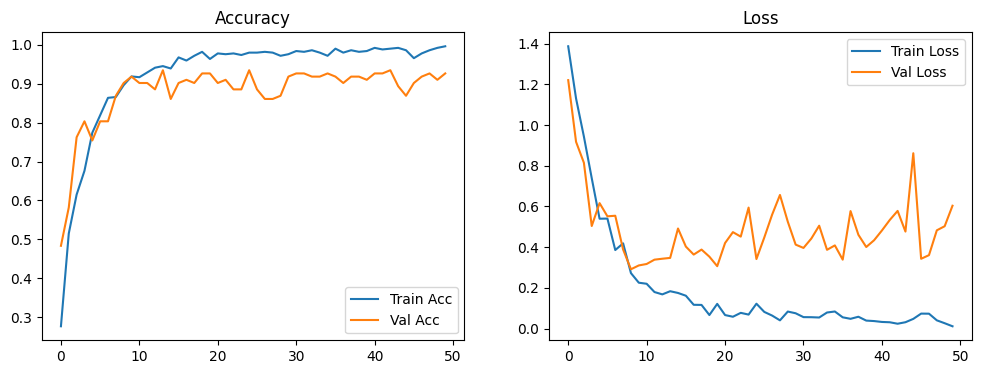

In [7]:
#Plot for accuracy and loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train Acc')
plt.plot(history.history['val_accuracy'],label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [9]:
#saving model
model.save('/content/lung_cancer_model.h5')

In [10]:
from google.colab import files
files.download('/content/lung_cancer_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# Install converter in Colab
!pip install tf2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 10.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>

In [13]:
import tf2onnx
import onnx

# Convert and save
model.output_names = ['output']
input_signature = [tf.TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input')]
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature=input_signature)
onnx.save(onnx_model, '/content/lung_cancer_model.onnx')

# Download it
from google.colab import files
files.download('/content/lung_cancer_model.onnx')

ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7df1d6659e40>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>